In [3]:
import pandas as pd

# Load with a more tolerant parser
fake = pd.read_csv('Fake.csv', engine='python', on_bad_lines='warn')
real = pd.read_csv('True.csv', engine='python', on_bad_lines='warn')

print("Fake news shape:", fake.shape)
print("Real news shape:", real.shape)

fake.head()

Fake news shape: (3089, 4)
Real news shape: (1217, 4)


/tmp/ipykernel_1935/3910999346.py:4: ParserWarning: Skipping line 3091: unexpected end of data

  fake = pd.read_csv('Fake.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_1935/3910999346.py:5: ParserWarning: Skipping line 1219: unexpected end of data

  real = pd.read_csv('True.csv', engine='python', on_bad_lines='warn')


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
import pandas as pd

# Add label column: 1 = real, 0 = fake
fake['label'] = 0
real['label'] = 1

# Combine into one dataset
df = pd.concat([fake, real], axis=0, ignore_index=True)

# Shuffle the rows so fake/real aren't grouped together
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Combined shape:", df.shape)
print()

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print()

# Check class balance
print("Class balance (0=fake, 1=real):")
print(df['label'].value_counts())
print()

# Check subject distribution
print("Subject distribution:")
print(df['subject'].value_counts())
print()

df.head()

Combined shape: (4306, 5)

Missing values per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Class balance (0=fake, 1=real):
label
0    3089
1    1217
Name: count, dtype: int64

Subject distribution:
subject
News            3089
politicsNews    1217
Name: count, dtype: int64



,title,text,subject,date,label
0,Papa John Attacks The NFL And First Amendment...,Rather than take personal responsibility for t...,News,"November 2, 2017",0
1,U.S. judge will likely rule next week on healt...,SAN FRANCISCO (Reuters) - A U.S. federal judge...,politicsNews,"October 18, 2017",1
2,This Bill Would Get Trump The Psychiatric Car...,Donald Trump is crazy. I don t say this flippa...,News,"February 8, 2017",0
3,WATCH: Ellen DeGeneres Cleverly Uses ‘Finding...,When Ellen DeGeneres found out that Donald Tru...,News,"January 31, 2017",0
4,House panels seek documents on Puerto Rico uti...,WASHINGTON (Reuters) - A U.S. congressional co...,politicsNews,"October 26, 2017",1


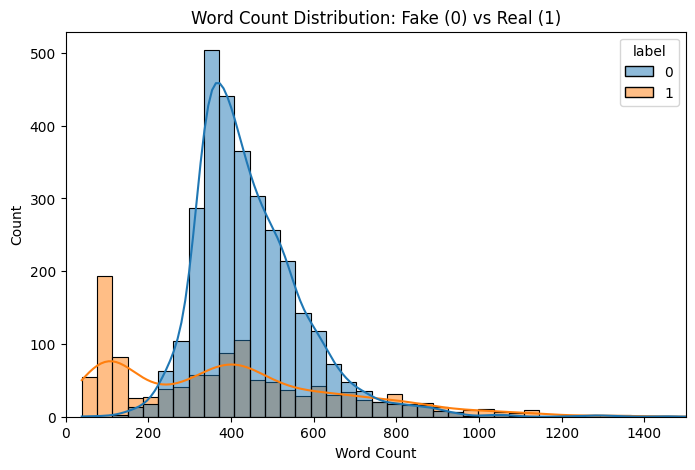

label
0    445.972159
1    402.009039
Name: word_count, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine title + text into one field we'll actually model on
df['content'] = df['title'] + " " + df['text']

# Add a word count feature for EDA purposes
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))

# Plot word count distribution by class
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='word_count', hue='label', bins=50, kde=True)
plt.title("Word Count Distribution: Fake (0) vs Real (1)")
plt.xlabel("Word Count")
plt.xlim(0, 1500)
plt.show()

# Average word count per class
print(df.groupby('label')['word_count'].mean())

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# Get top words for fake news
fake_text = df[df['label']==0]['content']
vec_fake = CountVectorizer(stop_words='english', max_features=20)
fake_counts = vec_fake.fit_transform(fake_text)
fake_words = pd.DataFrame(fake_counts.sum(axis=0), columns=vec_fake.get_feature_names_out()).T
fake_words.columns = ['count']
fake_words = fake_words.sort_values('count', ascending=False)

print("Top 20 words in FAKE news:")
print(fake_words)

Top 20 words in FAKE news:
                 count
trump            24300
president         4705
donald            4579
people            4335
just              4216
said              4051
twitter           3432
white             3128
image             2940
house             2937
like              2934
featured          2580
obama             2331
realdonaldtrump   2328
2017              2305
time              2246
news              2230
images            2180
getty             2138
russia            1984


In [7]:
# Get top words for real news
real_text = df[df['label']==1]['content']
vec_real = CountVectorizer(stop_words='english', max_features=20)
real_counts = vec_real.fit_transform(real_text)
real_words = pd.DataFrame(real_counts.sum(axis=0), columns=vec_real.get_feature_names_out()).T
real_words.columns = ['count']
real_words = real_words.sort_values('count', ascending=False)

print("Top 20 words in REAL news:")
print(real_words)

Top 20 words in REAL news:
             count
said          5465
trump         5115
tax           2878
house         2294
president     2018
republican    1900
senate        1779
reuters       1606
washington    1299
republicans   1168
state         1002
year           991
new            973
white          956
percent        950
donald         948
campaign       888
states         867
congress       858
committee      856


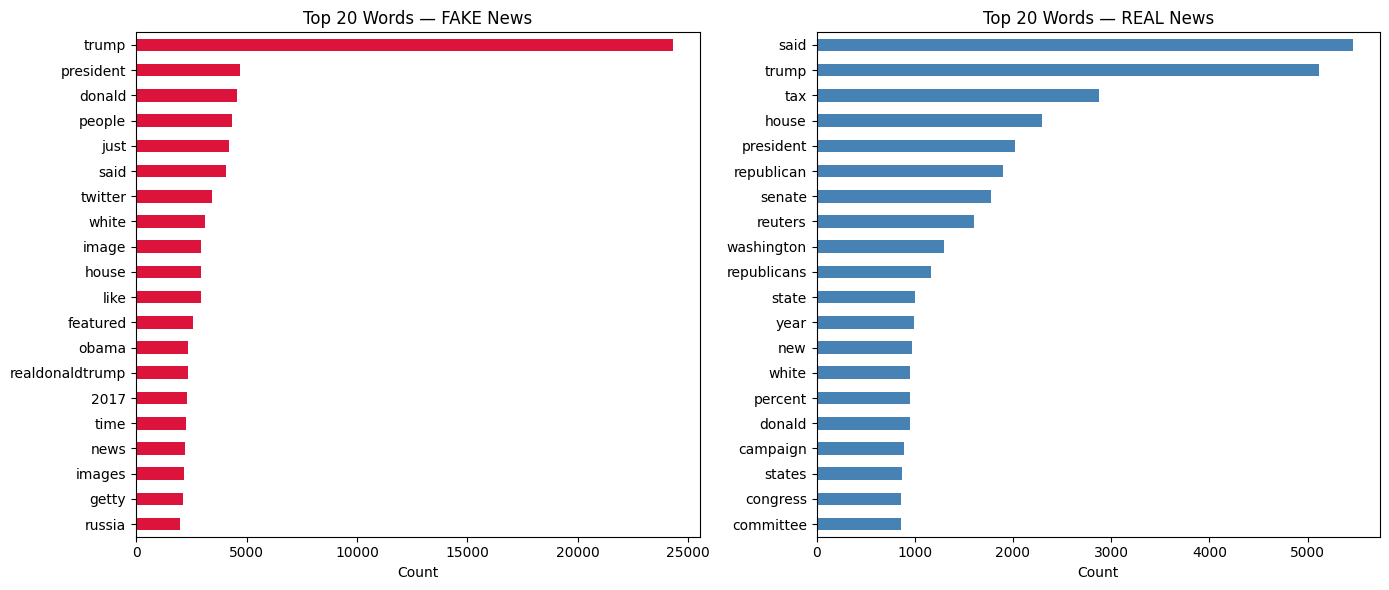

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

fake_words.sort_values('count').plot(kind='barh', y='count', ax=axes[0], color='crimson', legend=False)
axes[0].set_title("Top 20 Words — FAKE News")
axes[0].set_xlabel("Count")

real_words.sort_values('count').plot(kind='barh', y='count', ax=axes[1], color='steelblue', legend=False)
axes[1].set_title("Top 20 Words — REAL News")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig('top_words_comparison.png', dpi=150)
plt.show()

In [9]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Add dataset-specific noise words we discovered during EDA
noise_words = {'reuters', 'getty', 'image', 'images', 'featured', 'realdonaldtrump'}
stop_words = stop_words.union(noise_words)

def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)         # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)               # remove punctuation/numbers
    text = ' '.join([w for w in text.split() if w not in stop_words and len(w) > 2])  # remove stopwords + short tokens
    return text

df['clean_content'] = df['content'].apply(clean_text)

df[['content', 'clean_content']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,content,clean_content
0,Papa John Attacks The NFL And First Amendment...,papa john attacks nfl first amendment shtty pi...
1,U.S. judge will likely rule next week on healt...,judge likely rule next week healthcare payment...
2,This Bill Would Get Trump The Psychiatric Car...,bill would get trump psychiatric care desperat...
3,WATCH: Ellen DeGeneres Cleverly Uses ‘Finding...,watch ellen degeneres cleverly uses finding do...
4,House panels seek documents on Puerto Rico uti...,house panels seek documents puerto rico utilit...


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split BEFORE vectorizing, to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_content'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

Train size: 3444
Test size: 862
TF-IDF matrix shape (train): (3444, 5000)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Train
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluate
print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Results ===
Accuracy: 0.9872389791183295
Precision: 1.0
Recall: 0.9549180327868853
F1 Score: 0.9769392033542977

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       618
           1       1.00      0.95      0.98       244

    accuracy                           0.99       862
   macro avg       0.99      0.98      0.98       862
weighted avg       0.99      0.99      0.99       862



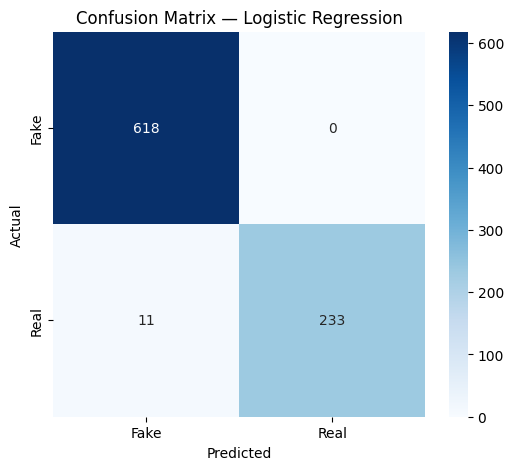

In [12]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix_lr.png', dpi=150)
plt.show()


In [13]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
Device name: Tesla T4


In [14]:
!pip install -q transformers

from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch

# Use a SMALLER sample for speed (full BERT fine-tuning on 7k docs is slow even on Colab GPU)
# We'll use a subset to keep training time reasonable for an internship project
df_sample = df.sample(n=4000, random_state=42).reset_index(drop=True)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    df_sample['clean_content'], df_sample['label'],
    test_size=0.2, random_state=42, stratify=df_sample['label']
)

print("BERT train size:", len(X_train_b))
print("BERT test size:", len(X_test_b))

BERT train size: 3200
BERT test size: 800


In [15]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
Device name: Tesla T4


In [16]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset = NewsDataset(X_train_b, y_train_b, tokenizer)
test_dataset = NewsDataset(X_test_b, y_test_b, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Number of training batches: 200
Number of test batches: 50


In [17]:
from transformers import BertForSequenceClassification
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=2e-5)

Using device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
from tqdm import tqdm

epochs = 2

for epoch in range(epochs):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} average loss: {avg_loss:.4f}")

Epoch 1/2: 100%|██████████| 200/200 [01:22<00:00,  2.43it/s, loss=0.00767]


Epoch 1 average loss: 0.1299


Epoch 2/2: 100%|██████████| 200/200 [01:23<00:00,  2.41it/s, loss=0.00247]

Epoch 2 average loss: 0.0270


In [19]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("=== BERT Results ===")
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall:", recall_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds))
print()
print(classification_report(all_labels, all_preds))

Evaluating: 100%|██████████| 50/50 [00:12<00:00,  4.07it/s]


=== BERT Results ===
Accuracy: 0.99
Precision: 0.9658119658119658
Recall: 1.0
F1 Score: 0.9826086956521739

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       574
           1       0.97      1.00      0.98       226

    accuracy                           0.99       800
   macro avg       0.98      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800



                          Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression (TF-IDF)    0.9874     0.9878  0.9854    0.9866
1             BERT (fine-tuned)    0.9900     0.9658  1.0000    0.9826


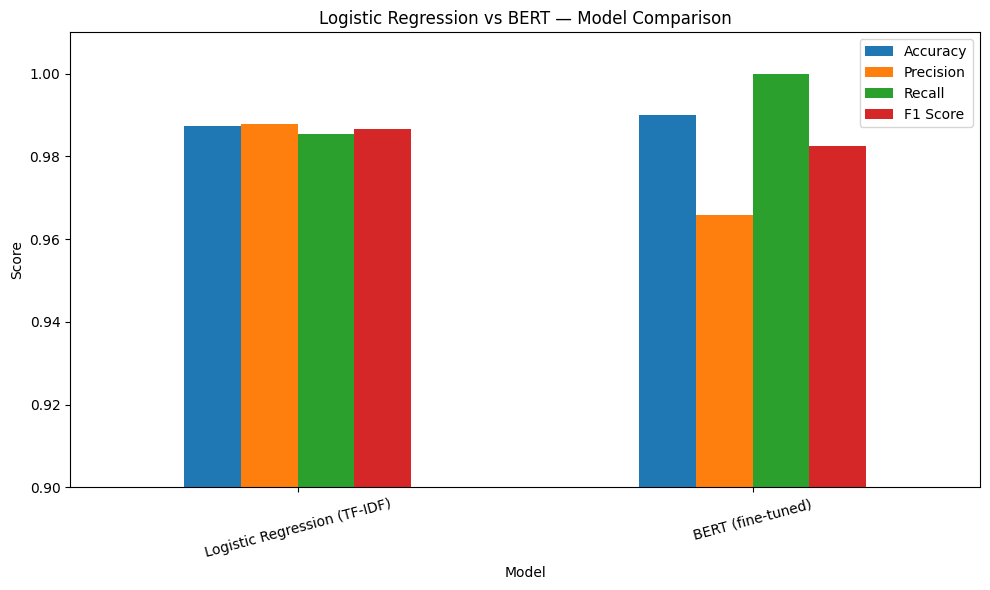

In [20]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF)', 'BERT (fine-tuned)'],
    'Accuracy': [0.9874, 0.99],
    'Precision': [0.9878, 0.9658],
    'Recall': [0.9854, 1.0000],
    'F1 Score': [0.9866, 0.9826]
})

print(comparison)

# Visual comparison
comparison.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(10,6), ylim=(0.9, 1.01)
)
plt.title('Logistic Regression vs BERT — Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()